# 04 - Object Classification

Train baseline and tree-based models to classify SDSS objects into STAR, GALAXY, and QSO using dereddened magnitudes and color index features.

This notebook intentionally excludes `z`, `zErr`, object IDs, and source file metadata from the feature set to avoid leakage.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score, accuracy_score

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
df = pd.read_csv(PROCESSED_DIR / "sdss_clean.csv")
df.shape

(150000, 18)

In [3]:
features = [
    "dered_u", "dered_g", "dered_r", "dered_i", "dered_z",
    "u_g", "g_r", "r_i", "i_z"
]
target = "object_class"

X = df[features]
y = df[target]

In [4]:
y.value_counts()

object_class
GALAXY    50000
QSO       50000
STAR      50000
Name: count, dtype: int64

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((120000, 9), (30000, 9))

In [6]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
print(classification_report(y_test, dummy.predict(X_test), zero_division=0))

              precision    recall  f1-score   support

      GALAXY       0.33      1.00      0.50     10000
         QSO       0.00      0.00      0.00     10000
        STAR       0.00      0.00      0.00     10000

    accuracy                           0.33     30000
   macro avg       0.11      0.33      0.17     30000
weighted avg       0.11      0.33      0.17     30000



Baseline: predicting the majority class alone gives 33% accuracy (as expected
with 3 balanced classes). Any real model needs to clear this bar by a wide
margin to be considered useful.

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
print(classification_report(y_test, logreg.predict(X_test_scaled), zero_division=0))

              precision    recall  f1-score   support

      GALAXY       0.68      0.74      0.71     10000
         QSO       0.78      0.90      0.84     10000
        STAR       0.69      0.52      0.59     10000

    accuracy                           0.72     30000
   macro avg       0.72      0.72      0.72     30000
weighted avg       0.72      0.72      0.72     30000



Logistic Regression reaches 72% accuracy, a big jump from baseline, but STAR
recall is notably weak (0.52), meaning nearly half of STAR objects are
misclassified. This lines up with the EDA finding that STAR and GALAXY overlap
heavily in color space; a linear decision boundary struggles to separate them.

In [8]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(classification_report(y_test, rf.predict(X_test), zero_division=0))

              precision    recall  f1-score   support

      GALAXY       0.91      0.92      0.92     10000
         QSO       0.92      0.94      0.93     10000
        STAR       0.92      0.90      0.91     10000

    accuracy                           0.92     30000
   macro avg       0.92      0.92      0.92     30000
weighted avg       0.92      0.92      0.92     30000



Random Forest jumps to 92% accuracy, with STAR recall recovering to 0.90,
far better than Logistic Regression. This suggests the class boundary between
STAR and GALAXY is non-linear: a model that can learn feature interactions
picks up separating patterns that a linear model misses.

In [9]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
print(classification_report(y_test, gb.predict(X_test), zero_division=0))

              precision    recall  f1-score   support

      GALAXY       0.89      0.90      0.89     10000
         QSO       0.91      0.92      0.91     10000
        STAR       0.90      0.86      0.88     10000

    accuracy                           0.90     30000
   macro avg       0.90      0.90      0.90     30000
weighted avg       0.90      0.90      0.90     30000



Gradient Boosting reaches 90% accuracy, slightly below Random Forest (92%)
but still far ahead of Logistic Regression. STAR remains the weakest class
(recall 0.86), consistent with the pattern seen across all models. Random
Forest currently performs best overall.

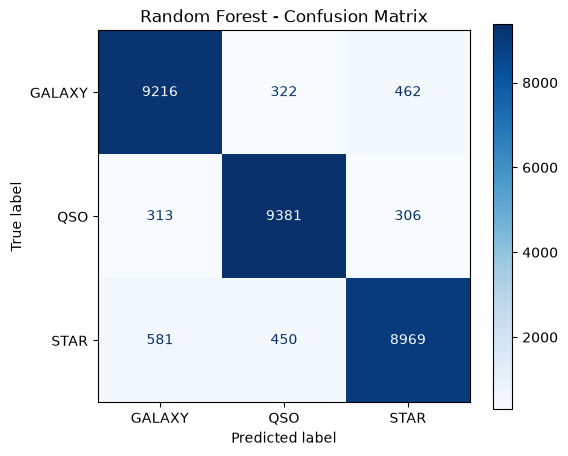

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, ax=ax, cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.show()

The confusion matrix confirms the EDA prediction: STAR is the most confused
class, misclassified as both GALAXY (581) and QSO (450) at similar rates.
GALAXY-QSO confusion is smaller and roughly symmetric (322 vs 313). This
matches the color-color contours from Phase 3, where STAR's density region
overlapped with both other classes rather than one specifically.

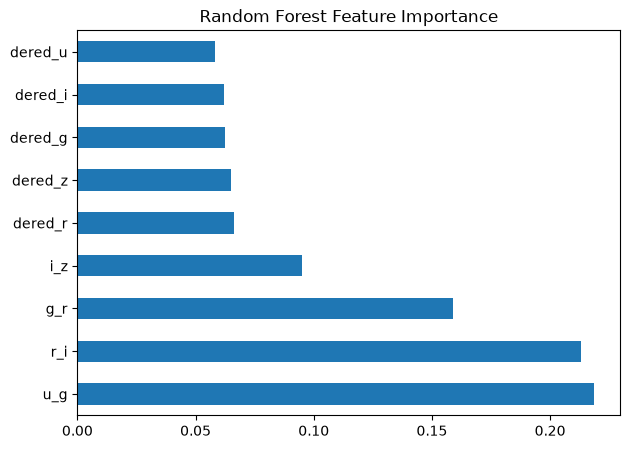

In [11]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
importances.plot(kind="barh", figsize=(7, 5), title="Random Forest Feature Importance")
plt.show()

Color indices receive the highest feature importance in Random Forest,
especially `u_g` and `r_i`. This supports the Phase 2 hypothesis that color
features carry strong class-separation signal. Since feature importance is
model-dependent and the input features are correlated, this should not be
treated as a universal physical conclusion.

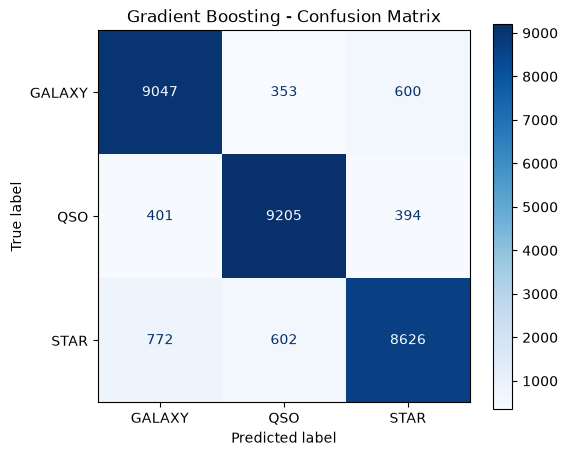

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(gb, X_test, y_test, ax=ax, cmap="Blues")
plt.title("Gradient Boosting - Confusion Matrix")
plt.show()

##### Gradient Boosting vs Random Forest - STAR Errors

In the confusion matrix, rows represent the actual class and columns represent
the predicted class.

For actual STAR objects:

- Random Forest misclassifies 581 STAR objects as GALAXY and 450 as QSO.
  Total STAR errors: `581 + 450 = 1,031`.

- Gradient Boosting misclassifies 772 STAR objects as GALAXY and 602 as QSO.
  Total STAR errors: `772 + 602 = 1,374`.

Gradient Boosting therefore makes 343 more STAR errors than Random Forest.
This supports keeping Random Forest as the stronger classification model for
this phase.

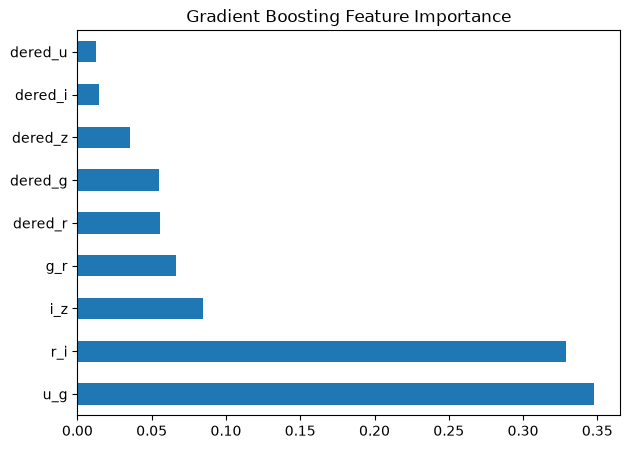

In [13]:
importances_gb = pd.Series(gb.feature_importances_, index=features).sort_values(ascending=False)
importances_gb.plot(kind="barh", figsize=(7, 5), title="Gradient Boosting Feature Importance")
plt.show()

Gradient Boosting also assigns most of its feature importance to `u_g` and
`r_i`. The agreement between both tree-based models strengthens the evidence
that color indices are useful for classification in this dataset, although the
exact importance values remain model-dependent.

In [14]:
models = {
    "Dummy": (dummy, X_test),
    "Logistic Regression": (logreg, X_test_scaled),
    "Random Forest": (rf, X_test),
    "Gradient Boosting": (gb, X_test),
}

results = []

for name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
    })

results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
results_df

,model,accuracy,macro_f1
2,Random Forest,0.918867,0.918796
3,Gradient Boosting,0.895933,0.895786
1,Logistic Regression,0.723433,0.715291
0,Dummy,0.333333,0.166667


#### Classification Notes

Random Forest is the strongest model in this phase, reaching the best overall performance while also recovering STAR recall compared to Logistic Regression. The gap between Logistic Regression and the tree-based models suggests the class boundaries are not purely linear.

The main remaining weakness is STAR confusion. This matches the EDA story: some STAR regions overlap with GALAXY and QSO in color space, so even the stronger models still make most of their mistakes around STAR.

For now, Random Forest is the candidate model to carry forward. The next step is galaxy redshift regression, where the target changes from object class to continuous `z`.